# AAI614: Data Science & its Applications

*Notebook 3.2: Practice with Data Cleaning*

<a href="https://colab.research.google.com/github/engmahmoudelhassan-cell/AAI614_Elhassan/blob/main/Week%203/Notebook3.2-M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

Exercise I. Load the following datafile from GitHub

In [3]:
url = "https://raw.githubusercontent.com/engmahmoudelhassan-cell/AAI614_Elhassan/main/Week%203/grads.csv"
try:
    grads = pd.read_csv(url)
except Exception:
    # Offline mode
    grads = pd.read_csv("grads.csv")

In [4]:
grads

,Student Name,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
0,George,20,NaN,NYU,3.0,$40k
1,Jerry,35,3.5,Columbia,5.0,$80k
2,Elaine,55,4.0,Columbia,4.2,$60k
3,Cosmo,5,2.0,City College,2.0,$25k
4,Newman,25,2.8,City College,0.0,$50k
5,Frank,35,3.0,Festivus Uni,NaN,$40k
6,Estelle,100,3.2,Festivus Uni,1.7,$0k
7,Leo,15,2.4,Festivus Uni,0.0,$35k
8,Rachel,50,4.0,Columbia,NaN,$75k


In [5]:
grads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student Name                9 non-null      object 
 1   Avg Hours Studies per Week  9 non-null      int64  
 2   GPA                         8 non-null      float64
 3   University                  9 non-null      object 
 4   Sense of Humour (0-5)       7 non-null      float64
 5   Salary                      9 non-null      object 
dtypes: float64(2), int64(1), object(3)
memory usage: 564.0+ bytes


#data cleaning

In [6]:
# Strip the spaces from the text columns
grads["Student Name"] = grads["Student Name"].str.strip()
grads["University"] = grads["University"].str.strip()

In [7]:
# Turn the salary into a plain number (in thousands)
if grads['Salary'].dtype == object:
    grads['Salary'] = grads['Salary'].str.replace(r'[^0-9.]', '', regex=True).astype(float)

In [8]:
grads

,Student Name,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
0,George,20,NaN,NYU,3.0,40.0
1,Jerry,35,3.5,Columbia,5.0,80.0
2,Elaine,55,4.0,Columbia,4.2,60.0
3,Cosmo,5,2.0,City College,2.0,25.0
4,Newman,25,2.8,City College,0.0,50.0
5,Frank,35,3.0,Festivus Uni,NaN,40.0
6,Estelle,100,3.2,Festivus Uni,1.7,0.0
7,Leo,15,2.4,Festivus Uni,0.0,35.0
8,Rachel,50,4.0,Columbia,NaN,75.0


**Question 1: Identify all the outliers in the above data.  Justify your answers using objective measures.**

In [9]:
# IQR fence rule: anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged as an outlier.
numeric_cols = ['GPA', 'Salary', 'Avg Hours Studies per Week', 'Sense of Humour (0-5)']

# 1. IQR Function
def get_outliers(df, column):
    # Drop NaN values specifically for the calculation
    data = df[column].dropna()
    if data.empty: return pd.DataFrame()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

# 2. Execution
for col in numeric_cols:
    outliers = get_outliers(grads, col)
    print(f"--- Outliers in {col} ---")
    print(outliers if not outliers.empty else "No outliers found.")
    print("\n")

--- Outliers in GPA ---
No outliers found.


--- Outliers in Salary ---
No outliers found.


--- Outliers in Avg Hours Studies per Week ---
  Student Name  Avg Hours Studies per Week  GPA    University  \
6      Estelle                         100  3.2  Festivus Uni   

   Sense of Humour (0-5)  Salary  
6                    1.7     0.0  


--- Outliers in Sense of Humour (0-5) ---
No outliers found.




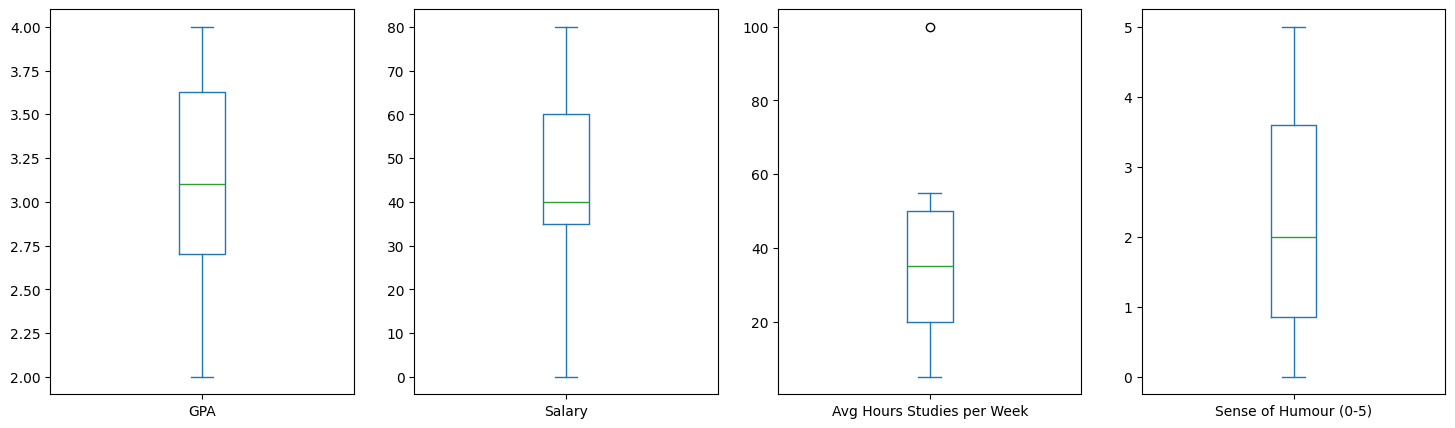

In [10]:
import matplotlib.pyplot as plt
# box plots only make sense for the numeric columns
grads[numeric_cols].plot(kind='box', subplots=True, figsize=(18, 5))
plt.show()

**Answer to Question 1.** Using the IQR fence rule, the only value that falls outside the fences is Estelle's 100 hours of study per week. Everyone else studies between 5 and 55 hours.on top of the 100 study hours she is the only graduate with a 0 salary. This must be a data entry problem rather than a real record. GPA, sense of humour and salary show no other outliers.

**Question 2: There are various data that are missing.  Fill-in the missing data or delete the rows/columns that you think you should delete.  Justify your answer**

In [11]:
#1 Identify the gaps
print(grads.isna().sum())

Student Name                  0
Avg Hours Studies per Week    0
GPA                           1
University                    0
Sense of Humour (0-5)         2
Salary                        0
dtype: int64


In [12]:
#2 Drop rows/columns that are more than half empty
row_threshold = grads.shape[1] // 2   # a row must have at least half its columns filled
col_threshold = grads.shape[0] // 2   # a column must have at least half its rows filled

# counts before cleaning
rows_before, cols_before = grads.shape

# drop sparse rows, then sparse columns
grads.dropna(axis=0, thresh=row_threshold, inplace=True)
grads.dropna(axis=1, thresh=col_threshold, inplace=True)

# counts after cleaning
rows_after, cols_after = grads.shape

print(f"Rows:    {rows_before} -> {rows_after}  (dropped {rows_before - rows_after})")
print(f"Columns: {cols_before} -> {cols_after}  (dropped {cols_before - cols_after})")

Rows:    9 -> 9  (dropped 0)
Columns: 6 -> 6  (dropped 0)


In [13]:
#3: Fill in the missing data
grads_median = grads.copy()

#3.1 Fill numeric columns with the MEDIAN
numeric_cols = ['GPA', 'Salary', 'Avg Hours Studies per Week', 'Sense of Humour (0-5)']
for col in numeric_cols:
    if grads_median[col].notna().any():          # only if the column has at least one number
        grads_median[col] = grads_median[col].fillna(grads_median[col].median())
    else:
        grads_median[col] = grads_median[col].fillna(0)   # fill if column is fully empty

#3.2 Fill categorical column with the MOST FREQUENT value
grads_median['University'] = grads_median['University'].fillna(grads_median['University'].mode()[0])

#3.3 Check the result
print("grads_median null counts:")
print(grads_median.isnull().sum())

grads_median null counts:
Student Name                  0
Avg Hours Studies per Week    0
GPA                           0
University                    0
Sense of Humour (0-5)         0
Salary                        0
dtype: int64


**Answer to Question 2.** I chose to fill rather than delete. With only nine rows, dropping George or Frank and Rachel would mean losing a third of the data, so I first checked with a threshold rule (drop only rows/columns that are more than half empty) and nothing qualified. I then filled the numeric gaps with the median, which is robust to the Estelle outlier from Q1. I also decided to keep Estelle's outlier in the data rather than remove it, since the median is not pulled by extreme values, so leaving it in does not affect the filled results. The University gap was filled with the most frequent value.

**Question 3: Reload the data and fill-in the data using mean method as well as the frequent method.**

In [14]:
import numpy as np
from sklearn.impute import SimpleImputer

# Reload a fresh copy of the data
try:
    grads_reload = pd.read_csv(url)
except Exception:
    grads_reload = pd.read_csv("grads.csv")

# basic cleaning
grads_reload["University"] = grads_reload["University"].str.strip()
grads_reload["Salary"] = grads_reload["Salary"].str.replace(r"[^0-9.]", "", regex=True).astype(float)

grads_mean = grads_reload.copy()
grads_freq = grads_reload.copy()

numeric_cols = grads_reload.select_dtypes(include=np.number).columns

# Mean method (numeric columns only)
grads_mean[numeric_cols] = SimpleImputer(strategy='mean').fit_transform(grads_mean[numeric_cols])

# Frequent method (works on every column, including text)
grads_freq[:] = SimpleImputer(strategy='most_frequent').fit_transform(grads_freq)

In [15]:
from IPython.display import display, HTML

tables = [
    ("ORIGINAL", grads,        "#F1C40F"),
    ("MEDIAN",   grads_median, "#2E7D32"),   
    ("MEAN",     grads_mean,   "#1565C0"),   
    ("FREQUENT", grads_freq,   "#C62828"), ]

for name, df, co in tables:
    display(HTML(f"<h3 style='color:{co}; font-weight:bold; margin:8px 0'>{name}</h3>"))
    display(df)

,Student Name,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
0,George,20,NaN,NYU,3.0,40.0
1,Jerry,35,3.5,Columbia,5.0,80.0
2,Elaine,55,4.0,Columbia,4.2,60.0
3,Cosmo,5,2.0,City College,2.0,25.0
4,Newman,25,2.8,City College,0.0,50.0
5,Frank,35,3.0,Festivus Uni,NaN,40.0
6,Estelle,100,3.2,Festivus Uni,1.7,0.0
7,Leo,15,2.4,Festivus Uni,0.0,35.0
8,Rachel,50,4.0,Columbia,NaN,75.0


,Student Name,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
0,George,20,3.1,NYU,3.0,40.0
1,Jerry,35,3.5,Columbia,5.0,80.0
2,Elaine,55,4.0,Columbia,4.2,60.0
3,Cosmo,5,2.0,City College,2.0,25.0
4,Newman,25,2.8,City College,0.0,50.0
5,Frank,35,3.0,Festivus Uni,2.0,40.0
6,Estelle,100,3.2,Festivus Uni,1.7,0.0
7,Leo,15,2.4,Festivus Uni,0.0,35.0
8,Rachel,50,4.0,Columbia,2.0,75.0


,Student Name,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
0,George,20.0,3.1125,NYU,3.000000,40.0
1,Jerry,35.0,3.5000,Columbia,5.000000,80.0
2,Elaine,55.0,4.0000,Columbia,4.200000,60.0
3,Cosmo,5.0,2.0000,City College,2.000000,25.0
4,Newman,25.0,2.8000,City College,0.000000,50.0
5,Frank,35.0,3.0000,Festivus Uni,2.271429,40.0
6,Estelle,100.0,3.2000,Festivus Uni,1.700000,0.0
7,Leo,15.0,2.4000,Festivus Uni,0.000000,35.0
8,Rachel,50.0,4.0000,Columbia,2.271429,75.0


,Student Name,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
0,George,20,4.0,NYU,3.0,40.0
1,Jerry,35,3.5,Columbia,5.0,80.0
2,Elaine,55,4.0,Columbia,4.2,60.0
3,Cosmo,5,2.0,City College,2.0,25.0
4,Newman,25,2.8,City College,0.0,50.0
5,Frank,35,3.0,Festivus Uni,0.0,40.0
6,Estelle,100,3.2,Festivus Uni,1.7,0.0
7,Leo,15,2.4,Festivus Uni,0.0,35.0
8,Rachel,50,4.0,Columbia,0.0,75.0


**Comparison of the three fill strategies versus baseline.**

In [16]:
from IPython.display import display, HTML

students = ["George", "Frank", "Rachel"]
affected = {"George": ["GPA"], "Frank": ["Sense of Humour (0-5)"], "Rachel": ["Sense of Humour (0-5)"]}

# (label, dataframe, color)
tables = [
    ("ORIGINAL (missing data)", grads,        "#F1C40F"),
    ("MEDIAN",                  grads_median, "#2E7D32"),
    ("MEAN",                    grads_mean,   "#1565C0"),
    ("FREQUENT",                grads_freq,   "#C62828"),
]

def make_highlighter(color):
    def _highlight(df):
        s = pd.DataFrame("", index=df.index, columns=df.columns)
        for stu, cols in affected.items():
            if stu in s.index:
                s.loc[stu, cols] = f"border: 2px solid {color}; font-weight: bold"
        return s
    return _highlight

for label, df, color in tables:
    sub = df.set_index("Student Name").loc[students]
    display(HTML(f"<h3 style='color:{color}; font-weight:bold; margin:12px 0 4px'>{label}</h3>"))
    display(sub.style.apply(make_highlighter(color), axis=None))

,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
Student Name,,,,,
George,20,nan,NYU,3.000000,40.000000
Frank,35,3.000000,Festivus Uni,nan,40.000000
Rachel,50,4.000000,Columbia,nan,75.000000


,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
Student Name,,,,,
George,20,3.100000,NYU,3.000000,40.000000
Frank,35,3.000000,Festivus Uni,2.000000,40.000000
Rachel,50,4.000000,Columbia,2.000000,75.000000


,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
Student Name,,,,,
George,20.000000,3.112500,NYU,3.000000,40.000000
Frank,35.000000,3.000000,Festivus Uni,2.271429,40.000000
Rachel,50.000000,4.000000,Columbia,2.271429,75.000000


,Avg Hours Studies per Week,GPA,University,Sense of Humour (0-5),Salary
Student Name,,,,,
George,20,4.000000,NYU,3.000000,40.000000
Frank,35,3.000000,Festivus Uni,0.000000,40.000000
Rachel,50,4.000000,Columbia,0.000000,75.000000


In [17]:
summary = []
frames = {"Mean fill": grads_mean, "Median fill": grads_median, "Frequent fill": grads_freq}
for col in ["GPA", "Sense of Humour (0-5)"]:
    obs = grads[col].dropna()
    summary.append([col, "Observed only", obs.mean(), obs.std()])
    for name, df in frames.items():
        s = df[col]
        summary.append([col, name, s.mean(), s.std()])
footprint = pd.DataFrame(summary, columns=["Column", "Strategy", "Mean", "Std (spread)"]).round(3)

(footprint.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center", "width": "150px", "border": "1px solid #ddd"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("width", "150px")]}])
    .format({"Mean": "{:.3f}", "Std (spread)": "{:.3f}"})
    .set_caption("Footprint of each fill method on the whole column"))

Column,Strategy,Mean,Std (spread)
GPA,Observed only,3.113,0.716
GPA,Mean fill,3.112,0.670
GPA,Median fill,3.111,0.670
GPA,Frequent fill,3.211,0.732
Sense of Humour (0-5),Observed only,2.271,1.933
Sense of Humour (0-5),Mean fill,2.271,1.674
Sense of Humour (0-5),Median fill,2.211,1.678
Sense of Humour (0-5),Frequent fill,1.767,1.951


**Conclusion:** The GPA column barely moves no matter which method I used, so for that one the choice does not really matter. The difference shows up in the humour scores. Mean and median keep the average close to what the original data was, but they tighten the spread a little because the filled values sit in the middle. The frequent method is the one we should avoid here, it drops the average from 2.27 down to 1.77 by repeating the value 0, which paints a worse picture than the actual data. So for these numeric columns I would stick with the mean or median and keep the frequent method for proper categories like university name.

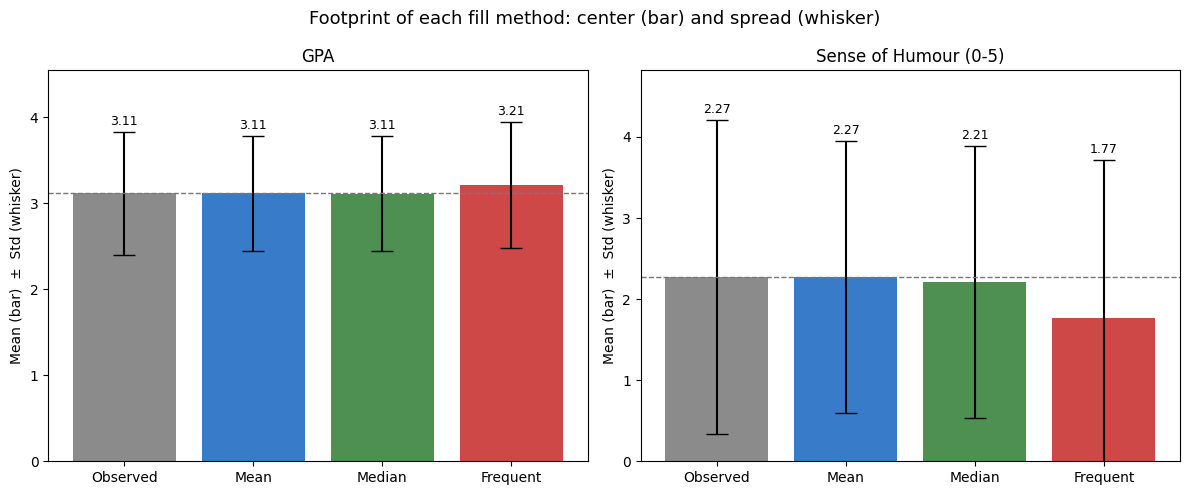

In [18]:
#Visulation 
import matplotlib.pyplot as plt

strategies = ["Observed", "Mean", "Median", "Frequent"]
colors     = ["#777777", "#1565C0", "#2E7D32", "#C62828"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["GPA", "Sense of Humour (0-5)"]):
    obs = grads[col].dropna()
    means = [obs.mean(), grads_mean[col].mean(), grads_median[col].mean(), grads_freq[col].mean()]
    stds  = [obs.std(),  grads_mean[col].std(),  grads_median[col].std(),  grads_freq[col].std()]
    bars = ax.bar(strategies, means, yerr=stds, capsize=8, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.axhline(obs.mean(), ls="--", lw=1, color="#777777")   # reference: original mean
    ax.set_title(col)
    ax.set_ylabel("Mean (bar)  ±  Std (whisker)")
    ax.set_ylim(0, max(means) + max(stds) + 0.6)

fig.suptitle("Footprint of each fill method: center (bar) and spread (whisker)", fontsize=13)
plt.tight_layout(); plt.show()

**Exercise II. Run the cell below to create a new dataframe called `df_miss`.  Its first column will contain some missing values.**

In [19]:
import pandas as pd
import numpy as np
import random

nrows = 10
ncols = 5

# set a seed for random number generation
np.random.seed(314)
# create an array filled with random data
data = np.array(np.random.rand(nrows, ncols))
# put the data to a pandas dataframe
df_miss = pd.DataFrame(data)
# rename the columns
df_miss.columns = ['col_'+str(ii) for ii in range(ncols)]

# randomly set some values to missing
ix0 = np.random.randint(nrows, size=3)
ix1 = np.random.randint(nrows, size=3)

df_miss.loc[ix0, 'col_0'] = np.nan
df_miss.loc[ix1, 'col_1'] = np.nan

print(df_miss)

      col_0     col_1     col_2     col_3     col_4
0       NaN       NaN  0.265048  0.783205  0.918001
1  0.827355       NaN  0.260480  0.911763  0.260757
2  0.766376  0.261531  0.122291  0.386006  0.840081
3       NaN       NaN  0.633110  0.584766  0.581232
4  0.677205  0.687155  0.438927  0.320927  0.570552
5       NaN  0.861074  0.834805  0.105766  0.060408
6  0.596882  0.792395  0.226356  0.535201  0.136066
7  0.372244  0.151977  0.429822  0.792706  0.406957
8  0.177850  0.909252  0.545331  0.100497  0.718721
9  0.978429  0.309776  0.260126  0.662900  0.139720


Impute the missing values (NaN) in `col_0` (but not `col_1`) with the median.  Store the values in the dataframe by using the parameter `inplace`.  Print the dataframe.

In [20]:
df_miss.fillna({'col_0': df_miss['col_0'].median()}, inplace=True)
print(df_miss)

      col_0     col_1     col_2     col_3     col_4
0  0.677205       NaN  0.265048  0.783205  0.918001
1  0.827355       NaN  0.260480  0.911763  0.260757
2  0.766376  0.261531  0.122291  0.386006  0.840081
3  0.677205       NaN  0.633110  0.584766  0.581232
4  0.677205  0.687155  0.438927  0.320927  0.570552
5  0.677205  0.861074  0.834805  0.105766  0.060408
6  0.596882  0.792395  0.226356  0.535201  0.136066
7  0.372244  0.151977  0.429822  0.792706  0.406957
8  0.177850  0.909252  0.545331  0.100497  0.718721
9  0.978429  0.309776  0.260126  0.662900  0.139720


Impute the missing values in `col_1` with value 0.  Store the values in the dataframe by using the parameter `inplace`.  Print the dataframe.

In [21]:
df_miss.fillna({'col_1': 0}, inplace=True)
print(df_miss)

      col_0     col_1     col_2     col_3     col_4
0  0.677205  0.000000  0.265048  0.783205  0.918001
1  0.827355  0.000000  0.260480  0.911763  0.260757
2  0.766376  0.261531  0.122291  0.386006  0.840081
3  0.677205  0.000000  0.633110  0.584766  0.581232
4  0.677205  0.687155  0.438927  0.320927  0.570552
5  0.677205  0.861074  0.834805  0.105766  0.060408
6  0.596882  0.792395  0.226356  0.535201  0.136066
7  0.372244  0.151977  0.429822  0.792706  0.406957
8  0.177850  0.909252  0.545331  0.100497  0.718721
9  0.978429  0.309776  0.260126  0.662900  0.139720


Mahmoud El Hassan
24/June/2026